### **MACHINE LEARNING**

### LAB 4: Regression and Classification Evaluation Metrics


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_curve, auc
)

**Task 1: Data Preparation**

1. Load the dataset using sklearn.


In [6]:
data = load_breast_cancer()

2. Convert into DataFrame and explore structure.

In [7]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

3. Check missing values and duplicates.


In [9]:
print(f"Missing Values:\n{X.isnull().sum().sum()}")
print(f"Duplicate Rows: {X.duplicated().sum()}")

Missing Values:
0
Duplicate Rows: 0


4. Apply feature scaling using StandardScaler and justify its importance.


In [10]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

KNN needs scaling because it calculates distance between points & StandardScaler makes all features equal size so the model can predict correctly.

**Task 2: Train-Test Split Analysis**

1. Split dataset into training and testing sets (80:20).

2. Repeat with 70:30 and 90:10 splits.

3. Compare performance variations across splits.


In [11]:
splits = [(0.20, "80:20"), (0.30, "70:30"), (0.10, "90:10")]
split_results = {}

for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42, stratify=y)
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    split_results[label] = acc
    print(f"Accuracy for {label} split: {acc:.4f}")
print("\n")

Accuracy for 80:20 split: 0.9649
Accuracy for 70:30 split: 0.9708
Accuracy for 90:10 split: 0.9825




4. Analyze how dataset splitting affects model stability and generalization.


90:10 split (Too small test): Test score changes wildly because test data is too small. Bad stability.

70:30 split (Too big test): Model does not have enough training data to learn. Bad generalization.

80:20 split (Just right): Perfect balance. Model learns well and test score stays steady and trustworthy.

**Task 3: KNN Model with Heuristic K Selection**

3.1 Heuristic Method for K Selection


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)

n_samples = X_train.shape[0]
heuristic_k = int(np.round(np.sqrt(n_samples)))
if heuristic_k % 2 == 0:
    heuristic_k += 1

print(f"Number of training samples (n): {n_samples}")
print(f"Calculated Heuristic K (sqrt(n) adjusted to odd): {heuristic_k}")

k_values = [k for k in range(max(1, heuristic_k - 5), heuristic_k + 6) if k > 0]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

Number of training samples (n): 455
Calculated Heuristic K (sqrt(n) adjusted to odd): 21


3.2 Model Training


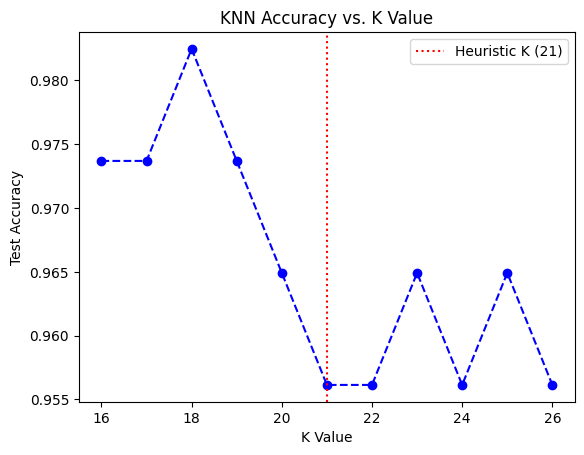

In [13]:
plt.figure()
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='b')
plt.axvline(x=heuristic_k, color='r', linestyle=':', label=f'Heuristic K ({heuristic_k})')
plt.title('KNN Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Test Accuracy')
plt.legend()
plt.show()

3. 3 Distance Matrix and Decision Boundary Mapping 


Mapping Decision Boundaries via PCA...


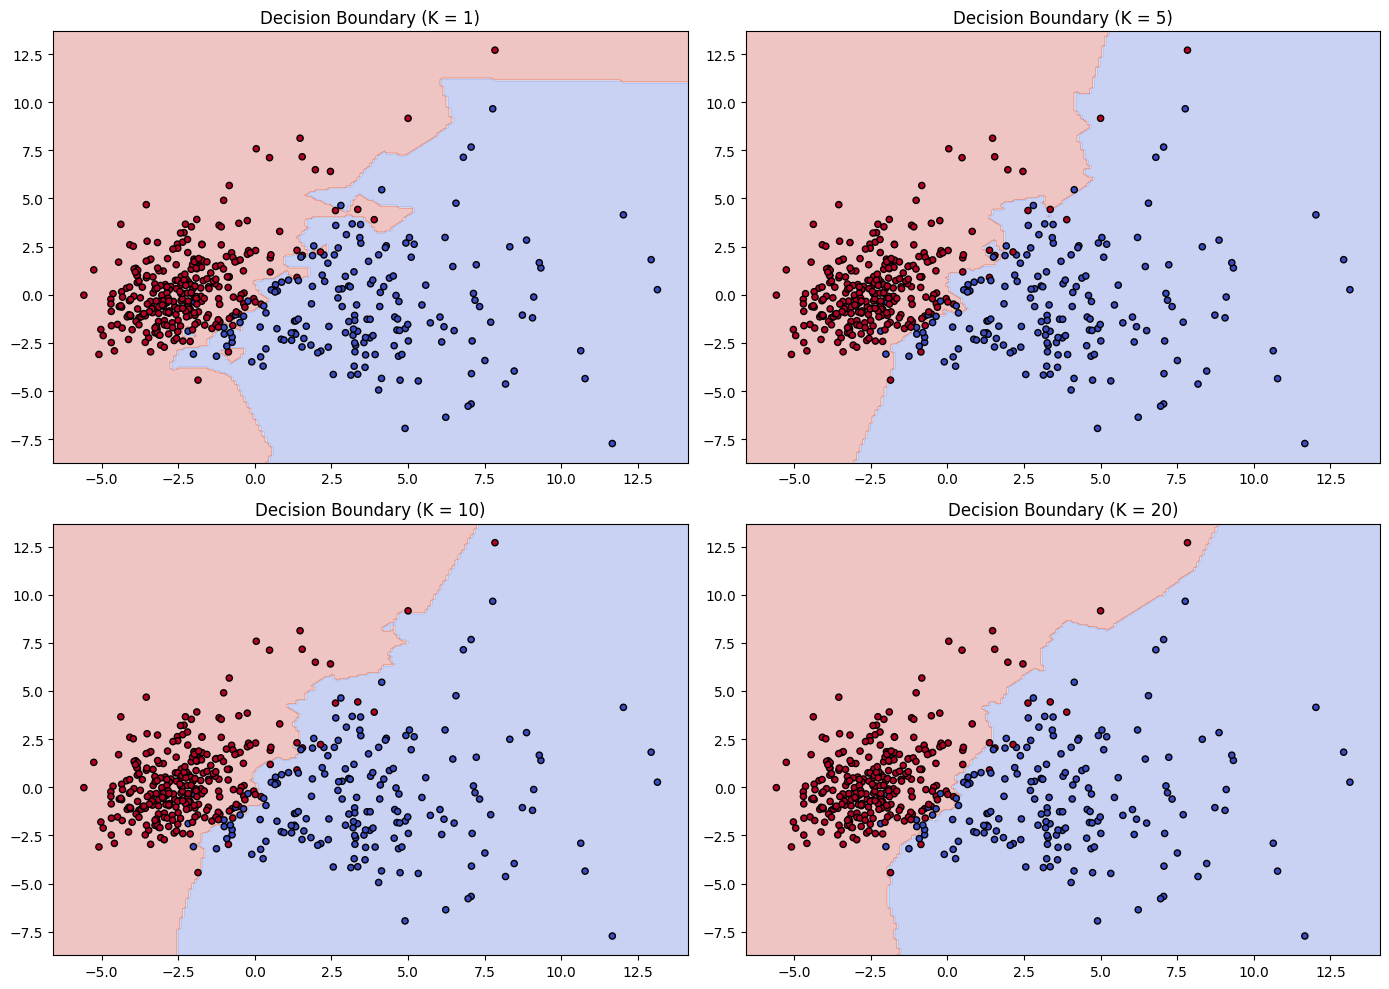

In [14]:
print("Mapping Decision Boundaries via PCA...")
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

k_boundaries = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

for i, k in enumerate(k_boundaries):
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_pca, y_train)
    Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    axes[i].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=20)
    axes[i].set_title(f'Decision Boundary (K = {k})')

plt.tight_layout()
plt.show()

**Task 4: Cross Validation**

In [15]:
print("\n--- Task 4: Cross Validation ---")
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_means = []

for k in k_values:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_scaled, y, cv=kf, scoring='accuracy')
    cv_means.append(scores.mean())
    print(f"10-Fold CV Mean Accuracy for K={k}: {scores.mean():.4f}")

optimal_k = k_values[np.argmax(cv_means)]
print(f"\nOptimal K identified via Cross-Validation: {optimal_k}")


--- Task 4: Cross Validation ---
10-Fold CV Mean Accuracy for K=16: 0.9595
10-Fold CV Mean Accuracy for K=17: 0.9560
10-Fold CV Mean Accuracy for K=18: 0.9595
10-Fold CV Mean Accuracy for K=19: 0.9560
10-Fold CV Mean Accuracy for K=20: 0.9577
10-Fold CV Mean Accuracy for K=21: 0.9542
10-Fold CV Mean Accuracy for K=22: 0.9577
10-Fold CV Mean Accuracy for K=23: 0.9542
10-Fold CV Mean Accuracy for K=24: 0.9542
10-Fold CV Mean Accuracy for K=25: 0.9542
10-Fold CV Mean Accuracy for K=26: 0.9542

Optimal K identified via Cross-Validation: 16


**Task 5: Classification Evaluation**


--- Task 5: Classification Evaluation ---
Accuracy:  0.9737
Precision: 0.9726
Recall:    0.9861
F1 Score:  0.9793


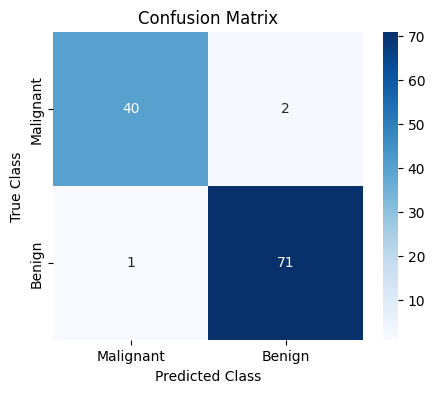

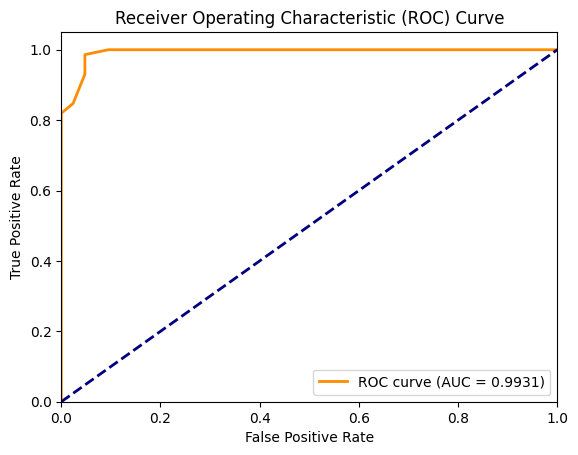

In [17]:
print("\n--- Task 5: Classification Evaluation ---")
final_model = KNeighborsClassifier(n_neighbors=optimal_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**Task 6: Comparative Study with Regression (Lab 3 Integration)**

*Error-Based vs Decision-Based:*

In Lab 3, we used Linear Regression to predict insurance charges. Here we used metrics like MAE, MSE, RMSE and R² Score. These metrics check how much error is there between actual and predicted values. In Lab 4, we used KNN Classification to predict whether the tumor is Malignant or Benign. Here we use Accuracy, Precision, Recall, F1 Score and AUC. These metrics check whether the prediction is correct or wrong.

*R² Score vs Accuracy:*

R² Score tells how well the regression model predicts the values. Higher R² means better model. Accuracy tells how many predictions are correct out of total predictions. Higher accuracy means better classification model.

*RMSE vs F1 Score:*

RMSE shows the average prediction error. Lower RMSE means the model predictions are closer to actual values. F1 Score is a combination of Precision and Recall. Higher F1 Score means better classification performance.

*MAE vs Confusion Matrix:*

MAE calculates the average difference between actual value and predicted value. Confusion Matrix shows how many predictions are correct and wrong. It contains TP, TN, FP and FN values.

*Regression vs Classification:*

Regression is used when the output is a number value like insurance charges. Classification is used when the output is a category like Malignant or Benign. So both use different evaluation methods.

*Inference:*

In Lab 3, MAE, MSE, RMSE and R² Score were used to evaluate the Linear Regression model. In Lab 4, Accuracy, Precision, Recall, F1 Score and AUC were used to evaluate the KNN Classification model. Accuracy alone is not enough in cancer prediction because even one missed cancer case can be dangerous. So Recall is more important because it helps identify most of the actual cancer patients.

*Hence regression focuses on reducing prediction error while Classification focuses on making the correct decision.*

**Task 7: Analytical Questions**

1. Why is KNN called a lazy learning algorithm?

KNN is called a lazy learning algorithm because it does not learn anything during training. It stores the data and makes predictions only when new data comes.

2. Why is feature scaling required in KNN?

Feature scaling is needed because KNN uses distance to make predictions. Scaling makes all features have equal importance.

3. Explain heuristic K selection using √n rule.

The √n rule means the value of K can be chosen as the square root of the total number of data points.

Example: If there are 100 samples,

K = √100 = 10

4. Why is cross-validation more reliable than a single train-test split?

Cross-validation tests the model many times using different data splits. So it gives more accurate and reliable results.

5. How does K affect bias-variance trade-off?

Small K → Low bias, High variance (can overfit).<br>
Large K → High bias, Low variance (can underfit).

6. Why is recall more important than accuracy in cancer prediction?

Recall is important because it finds most of the actual cancer patients. Missing a cancer patient is very dangerous.

7. What is the limitation of very large K values?

A very large K can make the model ignore important patterns and give wrong predictions. It may lead to underfitting.